In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
import os, tarfile, urllib.request, random
from PIL import Image

DATA_DIR = '/content/pets'
os.makedirs(DATA_DIR, exist_ok=True)

for url in ['https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz',
            'https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz']:
    fname = os.path.join(DATA_DIR, os.path.basename(url))
    if not os.path.exists(fname):
        print("Downloading", url)
        urllib.request.urlretrieve(url, fname)
    print("Extracting", fname)
    with tarfile.open(fname) as tar:
        tar.extractall(DATA_DIR)

IMAGES_DIR = os.path.join(DATA_DIR, 'images')
ANNOT_DIR = os.path.join(DATA_DIR, 'annotations')
NUM_CLASSES = 37

Extracting /content/pets/images.tar.gz


/tmp/ipykernel_85185/836400305.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Extracting /content/pets/annotations.tar.gz


In [3]:
def load_list(fname):
    """Parse annotations/*.txt: 'ImageName CLASS-ID SPECIES BREED-ID'."""
    items = []
    with open(os.path.join(ANNOT_DIR, fname)) as f:
        for line in f:
            if line.startswith('#'):
                continue
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            name, class_id = parts[0], int(parts[1]) - 1  # -> 0-based, 0..36
            path = os.path.join(IMAGES_DIR, name + '.jpg')
            if os.path.exists(path):
                items.append((path, class_id))
    return items

def filter_valid(items):
    """A few files in this dataset are corrupt/non-JPEG; drop them."""
    valid = []
    for path, label in items:
        try:
            with Image.open(path) as im:
                im.verify()
            valid.append((path, label))
        except Exception:
            pass
    return valid

trainval_items = filter_valid(load_list('trainval.txt'))
test_items = filter_valid(load_list('test.txt'))

random.seed(42)
random.shuffle(trainval_items)
val_size = int(0.2 * len(trainval_items))
val_items = trainval_items[:val_size]
train_items = trainval_items[val_size:]

print("Train:", len(train_items), "| Val:", len(val_items),
      "| Test:", len(test_items), "| Classes:", NUM_CLASSES)

Train: 2944 | Val: 736 | Test: 3669 | Classes: 37


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_QUICK = 15   # keep small for CPU; increase on GPU

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

def make_dataset(items):
    paths = [p for p, _ in items]
    labels = [l for _, l in items]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    return ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

ds_train = make_dataset(train_items)
ds_val   = make_dataset(val_items)
ds_test  = make_dataset(test_items)

def make_batches(ds, shuffle=False, batch_size=BATCH_SIZE):
    if shuffle:
        ds = ds.shuffle(500)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_batches = make_batches(ds_train, shuffle=True)
val_batches   = make_batches(ds_val)
test_batches  = make_batches(ds_test)

In [5]:
def build_model(init='glorot_uniform', dropout_rate=0.5, l2_reg=0.0,
                 use_bn=True, trainable_base=False, base_model=None):
    if base_model is None:
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            include_top=False,
            weights='imagenet'
        )
    base_model.trainable = trainable_base

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Dense(
        128, activation='relu',
        kernel_initializer=init,
        kernel_regularizer=regularizers.l2(l2_reg) if l2_reg > 0 else None
    )(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', kernel_initializer=init)(x)

    model = models.Model(inputs, outputs)
    return model, base_model

In [6]:
inits = ['zeros', 'random_normal', 'glorot_uniform', 'he_normal']
init_histories = {}

for init in inits:
    print(f"\nTraining with {init} initialization...")
    model, _ = build_model(init=init, dropout_rate=0.0, use_bn=False)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(train_batches, validation_data=val_batches, epochs=EPOCHS_QUICK, verbose=1)
    init_histories[init] = hist.history


Training with zeros initialization...
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 166ms/step - accuracy: 0.0248 - loss: 3.6113 - val_accuracy: 0.0163 - val_loss: 3.6117
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.0262 - loss: 3.6111 - val_accuracy: 0.0163 - val_loss: 3.6124
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.0279 - loss: 3.6109 - val_accuracy: 0.0163 - val_loss: 3.6130
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.0282 - loss: 3.6107 - val_accuracy: 0.0163 - val_loss: 3.6136
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.0299 - loss: 3.6107 - val_accuracy: 0.0163 - val_loss: 3.6141
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.0268 - loss: 3.6106 - val_accuracy: 0.0163 - val_loss: 3.6147
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.0299 - loss: 3.6105 - val_accuracy: 0.0163 - val_loss: 3.6151
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy:

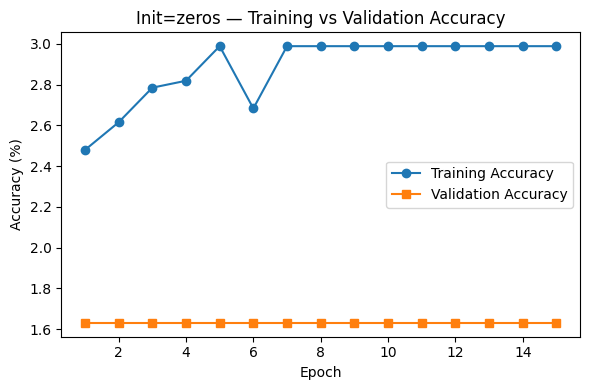

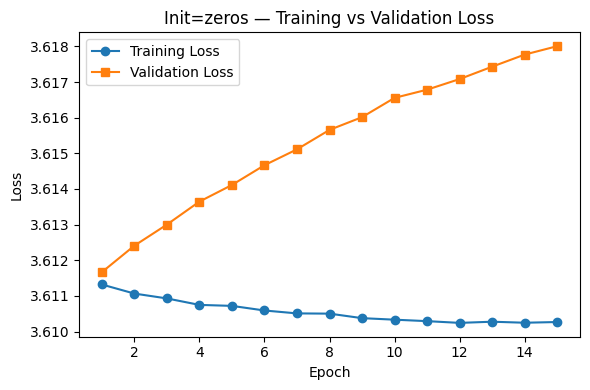

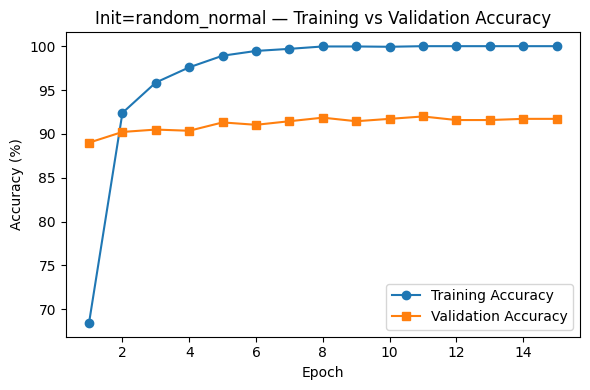

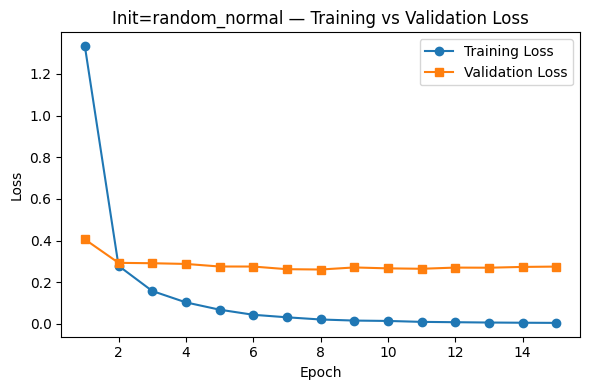

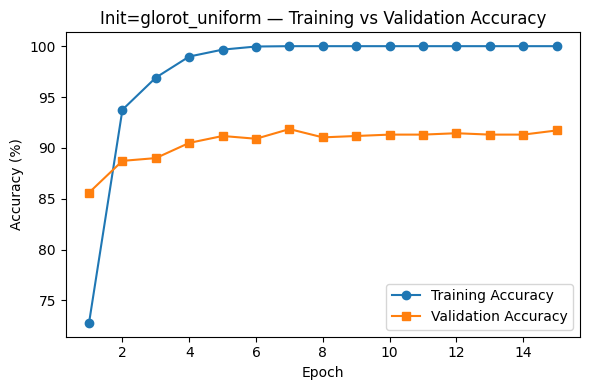

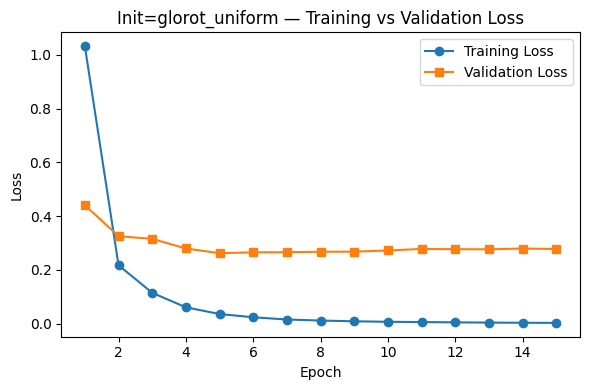

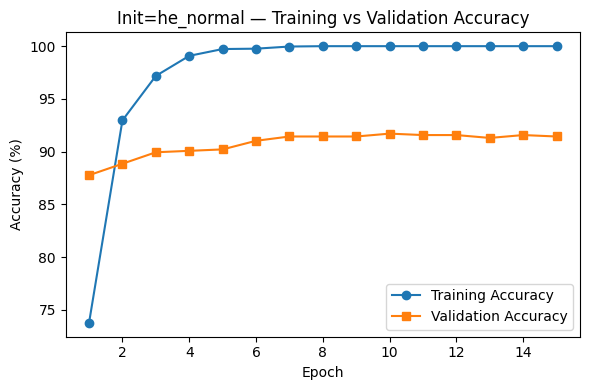

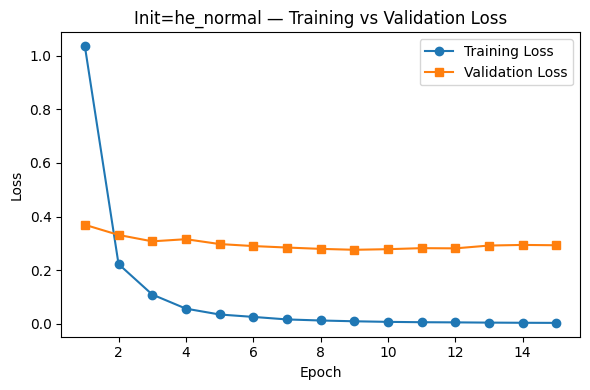

In [8]:
import os
os.makedirs('plots5', exist_ok=True)

for init, h in init_histories.items():
    epochs = range(1, len(h['accuracy']) + 1)

    plt.figure(figsize=(6,4))
    plt.plot(epochs, [a*100 for a in h['accuracy']], marker='o', label='Training Accuracy')
    plt.plot(epochs, [a*100 for a in h['val_accuracy']], marker='s', label='Validation Accuracy')
    plt.title(f'Init={init} — Training vs Validation Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'plots5/init_{init}_accuracy.png')
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(epochs, h['loss'], marker='o', label='Training Loss')
    plt.plot(epochs, h['val_loss'], marker='s', label='Validation Loss')
    plt.title(f'Init={init} — Training vs Validation Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'plots5/init_{init}_loss.png')
    plt.show()

In [9]:
reg_configs = {
    'No Regularization':     dict(dropout_rate=0.0, l2_reg=0.0,  use_bn=False),
    'L2 Regularization':     dict(dropout_rate=0.0, l2_reg=0.01, use_bn=False),
    'Dropout':                dict(dropout_rate=0.5, l2_reg=0.0,  use_bn=False),
    'Batch Normalization':    dict(dropout_rate=0.0, l2_reg=0.0,  use_bn=True),
}
reg_histories = {}
for name, cfg in reg_configs.items():
    print(f"\nTraining: {name}")
    model, _ = build_model(init='he_normal', **cfg)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(train_batches, validation_data=val_batches, epochs=EPOCHS_QUICK, verbose=1)
    reg_histories[name] = hist.history


Training: No Regularization
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 143ms/step - accuracy: 0.7238 - loss: 1.0617 - val_accuracy: 0.8899 - val_loss: 0.3862
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.9338 - loss: 0.2231 - val_accuracy: 0.9035 - val_loss: 0.3081
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9728 - loss: 0.1119 - val_accuracy: 0.9049 - val_loss: 0.2906
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.9891 - loss: 0.0636 - val_accuracy: 0.8995 - val_loss: 0.3029
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.9956 - loss: 0.0362 - val_accuracy: 0.9117 - val_loss: 0.2780
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.9993 - loss: 0.0195 - val_accuracy: 0.9130 - val_loss: 0.2821
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.9997 - loss: 0.0142 - val_accuracy: 0.9117 - val_loss: 0.2895
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 1.0000 - l

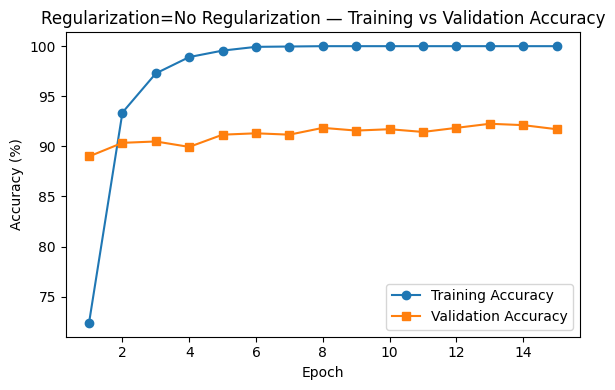

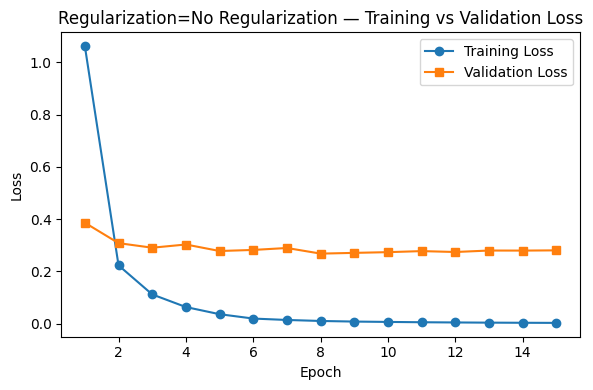

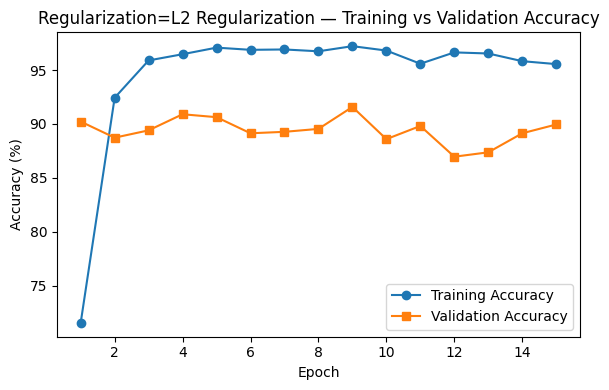

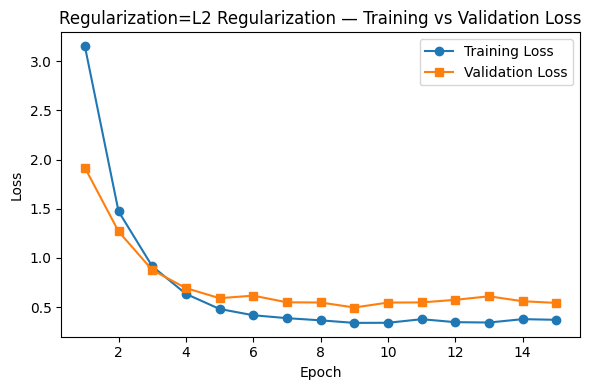

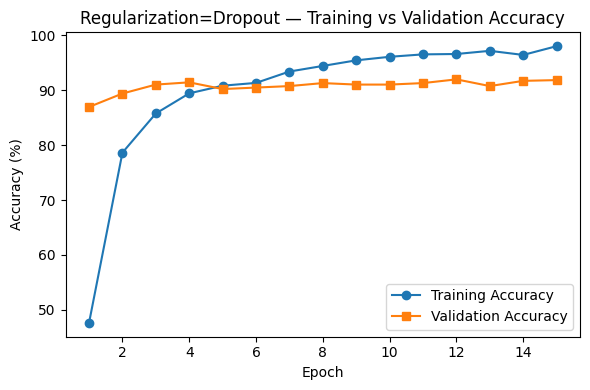

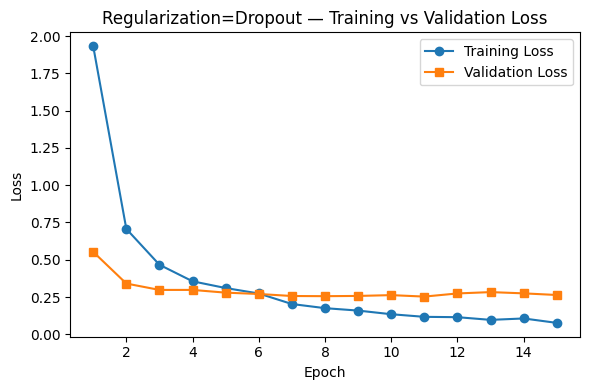

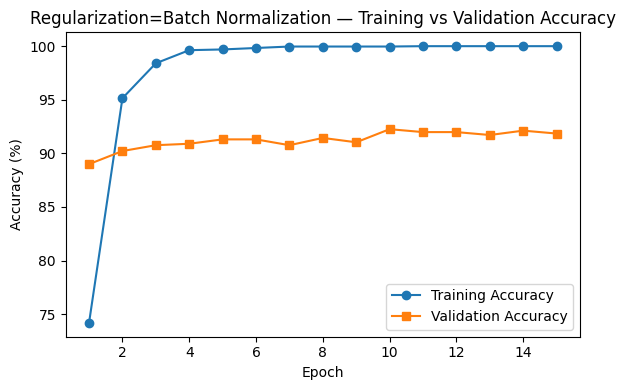

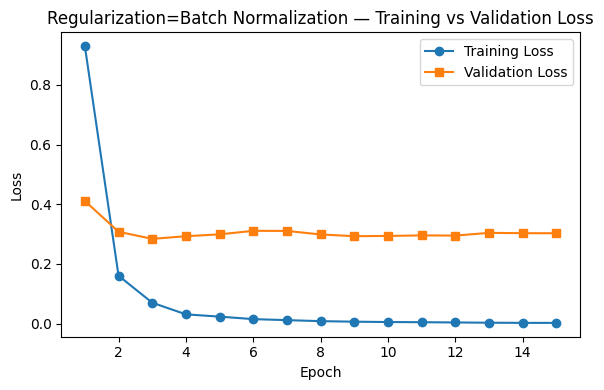

In [10]:
for name, h in reg_histories.items():
    epochs = range(1, len(h['accuracy']) + 1)
    tag = name.lower().replace(' ', '_')

    plt.figure(figsize=(6,4))
    plt.plot(epochs, [a*100 for a in h['accuracy']], marker='o', label='Training Accuracy')
    plt.plot(epochs, [a*100 for a in h['val_accuracy']], marker='s', label='Validation Accuracy')
    plt.title(f'Regularization={name} — Training vs Validation Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'plots5/reg_{tag}_accuracy.png')
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(epochs, h['loss'], marker='o', label='Training Loss')
    plt.plot(epochs, h['val_loss'], marker='s', label='Validation Loss')
    plt.title(f'Regularization={name} — Training vs Validation Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'plots5/reg_{tag}_loss.png')
    plt.show()

In [ ]:
x = np.array([2, 4, 6, 8], dtype=float)
mu = x.mean()
var = x.var()          # population variance, matches the manual's formula
x_hat = (x - mu) / np.sqrt(var + 1e-8)
gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta

print("Mean (mu_B):", mu)
print("Variance (sigma_B^2):", var)
print("Normalized (x_hat):", np.round(x_hat, 3))
print("Output y (gamma=1, beta=0):", np.round(y, 3))

Mean (mu_B): 5.0
Variance (sigma_B^2): 5.0
Normalized (x_hat): [-1.342 -0.447  0.447  1.342]
Output y (gamma=1, beta=0): [-1.342 -0.447  0.447  1.342]


Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 144ms/step - accuracy: 0.7449 - loss: 0.8845 - val_accuracy: 0.8832 - val_loss: 0.4223
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9545 - loss: 0.1539 - val_accuracy: 0.8981 - val_loss: 0.2944
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.9895 - loss: 0.0598 - val_accuracy: 0.9035 - val_loss: 0.2872
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.9949 - loss: 0.0354 - val_accuracy: 0.9035 - val_loss: 0.2979
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.9980 - loss: 0.0220 - val_accuracy: 0.9076 - val_loss: 0.3108
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9993 - loss: 0.0143 - val_accuracy: 0.9022 - val_loss: 0.2932
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.9983 - loss: 0.0110 - val_accuracy: 0.9076 - val_loss: 0.3055
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - accuracy: 0.9997 - loss: 0.0093 - val_accuracy: 

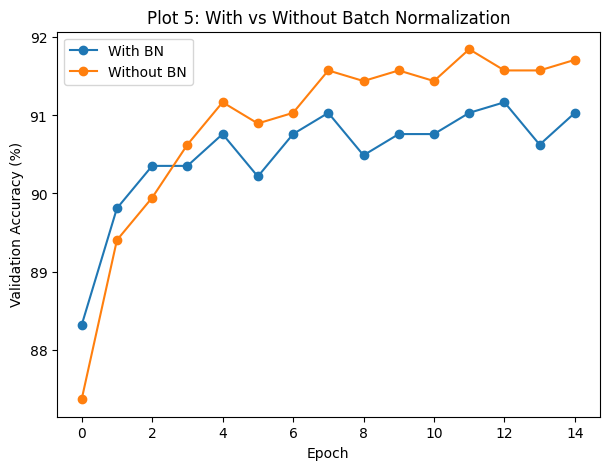

In [ ]:
# Plot 5: With vs Without Batch Normalization
bn_histories = {}
for name, use_bn in [('With BN', True), ('Without BN', False)]:
    model, _ = build_model(init='he_normal', dropout_rate=0.0, use_bn=use_bn)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(train_batches, validation_data=val_batches, epochs=EPOCHS_QUICK, verbose=1)
    bn_histories[name] = hist.history

plt.figure(figsize=(7,5))
for name, h in bn_histories.items():
    plt.plot([a*100 for a in h['val_accuracy']], marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 5: With vs Without Batch Normalization')
plt.legend(); plt.show()

In [ ]:
optimizer_configs = {
    'SGD':      optimizers.SGD(learning_rate=0.01),
    'Momentum': optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSProp':  optimizers.RMSprop(learning_rate=0.001),
    'Adam':     optimizers.Adam(learning_rate=0.001),
}
opt_histories, opt_times = {}, {}

for name, opt in optimizer_configs.items():
    print(f"\nTraining with {name}")
    model, _ = build_model(init='he_normal', dropout_rate=0.5, use_bn=True)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    hist = model.fit(train_batches, validation_data=val_batches, epochs=EPOCHS_QUICK, verbose=1)
    opt_times[name] = time.time() - start
    opt_histories[name] = hist.history


Training with SGD
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.2571 - loss: 3.0308 - val_accuracy: 0.7378 - val_loss: 1.5533
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.6087 - loss: 1.4065 - val_accuracy: 0.8438 - val_loss: 0.7527
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.7096 - loss: 0.9854 - val_accuracy: 0.8641 - val_loss: 0.4982
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.7629 - loss: 0.8041 - val_accuracy: 0.8791 - val_loss: 0.4067
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.8010 - loss: 0.6733 - val_accuracy: 0.8845 - val_loss: 0.3647
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.8247 - loss: 0.5778 - val_accuracy: 0.8859 - val_loss: 0.3435
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.8438 - loss: 0.5084 - val_accuracy: 0.8899 - val_loss: 0.3252
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.8560 - loss: 0.48

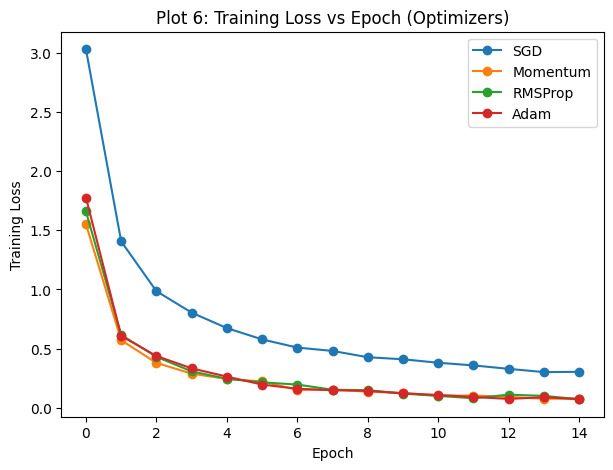

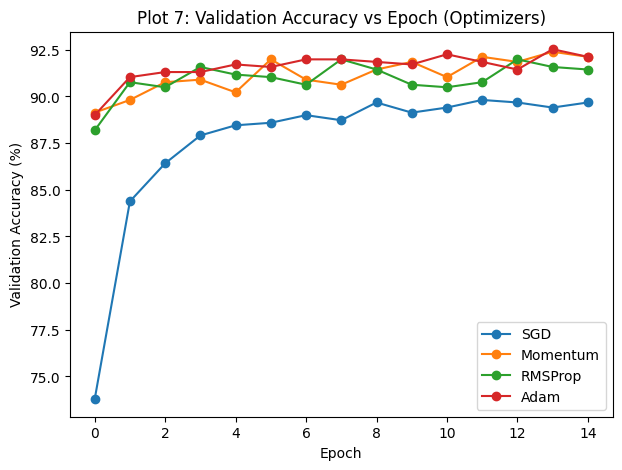

,Optimizer,Final Loss,Best Val. Accuracy (%),Epoch to Converge,Time (s)
0,SGD,0.3034,89.81,12,162.6
1,Momentum,0.0775,92.39,14,160.7
2,RMSProp,0.0721,91.98,8,170.0
3,Adam,0.0719,92.53,14,179.2


In [ ]:
# Plot 6 & 7
plt.figure(figsize=(7,5))
for name, h in opt_histories.items():
    plt.plot(h['loss'], marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('Plot 6: Training Loss vs Epoch (Optimizers)')
plt.legend(); plt.show()

plt.figure(figsize=(7,5))
for name, h in opt_histories.items():
    plt.plot([a*100 for a in h['val_accuracy']], marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 7: Validation Accuracy vs Epoch (Optimizers)')
plt.legend(); plt.show()

# Optimizer summary table
rows = []
for name, h in opt_histories.items():
    best_val = max(h['val_accuracy']) * 100
    epoch_conv = int(np.argmax(h['val_accuracy'])) + 1
    rows.append([name, round(h['loss'][-1], 4), round(best_val, 2), epoch_conv, round(opt_times[name], 1)])
opt_table = pd.DataFrame(rows, columns=['Optimizer', 'Final Loss', 'Best Val. Accuracy (%)', 'Epoch to Converge', 'Time (s)'])
opt_table

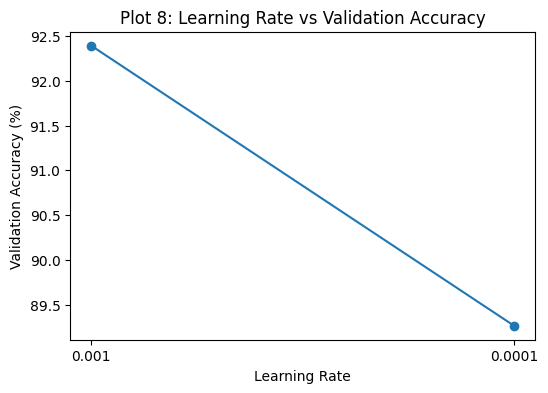

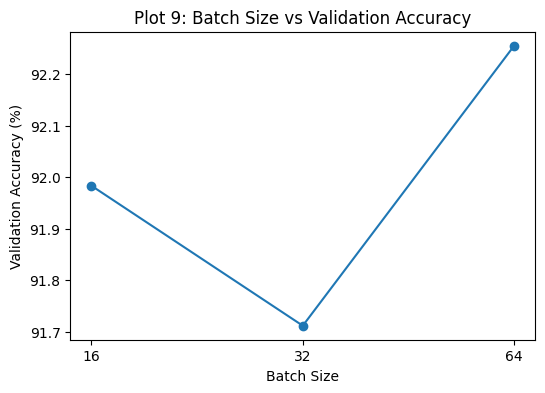

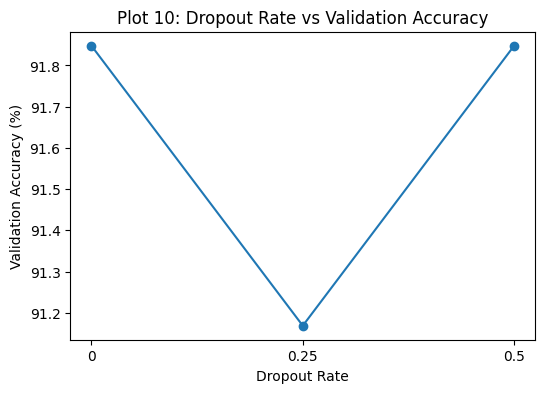

In [ ]:
def train_eval_config(lr=0.001, batch_size=32, dropout=0.5, optimizer_name='adam', epochs=EPOCHS_QUICK):
    model, _ = build_model(init='he_normal', dropout_rate=dropout, use_bn=True)
    opt = optimizers.Adam(learning_rate=lr) if optimizer_name == 'adam' else optimizers.SGD(learning_rate=lr, momentum=0.9)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    tb = make_batches(ds_train, shuffle=True, batch_size=batch_size)
    vb = make_batches(ds_val, batch_size=batch_size)
    hist = model.fit(tb, validation_data=vb, epochs=epochs, verbose=0)
    return max(hist.history['val_accuracy']) * 100

# Learning Rate: Plot 8
lr_results = {lr: train_eval_config(lr=lr) for lr in [0.001, 0.0001]}
plt.figure(figsize=(6,4))
plt.plot(list(map(str, lr_results.keys())), list(lr_results.values()), marker='o')
plt.xlabel('Learning Rate'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 8: Learning Rate vs Validation Accuracy'); plt.show()

# Batch Size: Plot 9
bs_results = {bs: train_eval_config(batch_size=bs) for bs in [16, 32, 64]}
plt.figure(figsize=(6,4))
plt.plot(list(map(str, bs_results.keys())), list(bs_results.values()), marker='o')
plt.xlabel('Batch Size'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 9: Batch Size vs Validation Accuracy'); plt.show()

# Dropout Rate: Plot 10
do_results = {do: train_eval_config(dropout=do) for do in [0, 0.25, 0.5]}
plt.figure(figsize=(6,4))
plt.plot(list(map(str, do_results.keys())), list(do_results.values()), marker='o')
plt.xlabel('Dropout Rate'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 10: Dropout Rate vs Validation Accuracy'); plt.show()

In [ ]:

# Case A: Feature Extraction (frozen base)
fe_model, base = build_model(init='he_normal', dropout_rate=0.5, use_bn=True, trainable_base=False)
fe_model.compile(optimizer=optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
fe_hist = fe_model.fit(train_batches, validation_data=val_batches, epochs=EPOCHS_QUICK, verbose=1)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - accuracy: 0.5397 - loss: 1.7771 - val_accuracy: 0.8723 - val_loss: 0.5148
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.8227 - loss: 0.5754 - val_accuracy: 0.8940 - val_loss: 0.3268
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.8699 - loss: 0.4274 - val_accuracy: 0.9076 - val_loss: 0.2913
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.9001 - loss: 0.3176 - val_accuracy: 0.9103 - val_loss: 0.2714
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.9185 - loss: 0.2338 - val_accuracy: 0.9103 - val_loss: 0.2773
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.9321 - loss: 0.2055 - val_accuracy: 0.9171 - val_loss: 0.2772
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9453 - loss: 0.1741 - val_accuracy: 0.9076 - val_loss: 0.2854
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.9524 - loss: 0.1424 - val_accuracy: 0

In [ ]:

# Case B: Fine-Tuning (unfreeze top layers of the base, small LR)
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

fe_model.compile(optimizer=optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ft_hist = fe_model.fit(train_batches, validation_data=val_batches, epochs=EPOCHS_QUICK, verbose=1)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 193ms/step - accuracy: 0.8971 - loss: 0.3233 - val_accuracy: 0.9076 - val_loss: 0.3282
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.9124 - loss: 0.2659 - val_accuracy: 0.9035 - val_loss: 0.3335
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.9256 - loss: 0.2226 - val_accuracy: 0.9090 - val_loss: 0.3308
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9324 - loss: 0.1975 - val_accuracy: 0.9144 - val_loss: 0.3296
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.9382 - loss: 0.1627 - val_accuracy: 0.9117 - val_loss: 0.3268
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9470 - loss: 0.1745 - val_accuracy: 0.9185 - val_loss: 0.3204
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.9487 - loss: 0.1520 - val_accuracy: 0.9198 - val_loss: 0.3110
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9558 - loss: 0.1429 - val_accuracy: 

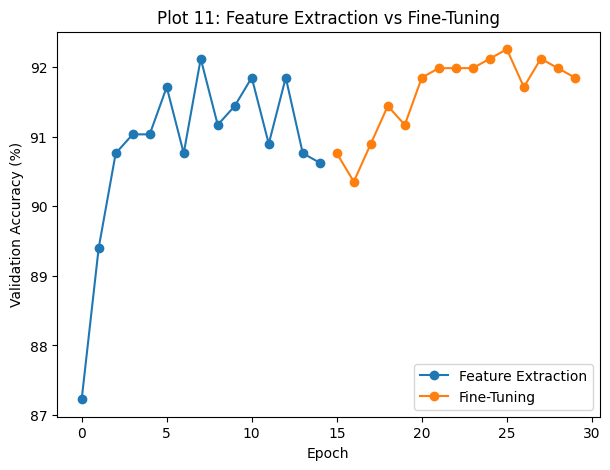

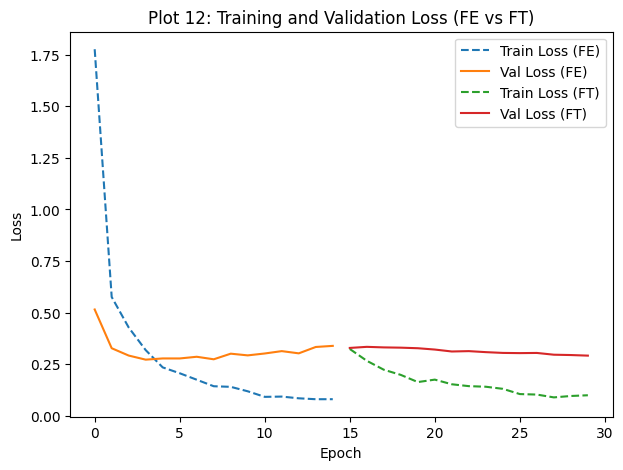

In [ ]:
# Plot 11: Feature Extraction vs Fine-Tuning
offset = len(fe_hist.history['val_accuracy'])
ft_epochs = list(range(offset, offset + len(ft_hist.history['val_accuracy'])))

plt.figure(figsize=(7,5))
plt.plot(range(offset), [a*100 for a in fe_hist.history['val_accuracy']], marker='o', label='Feature Extraction')
plt.plot(ft_epochs, [a*100 for a in ft_hist.history['val_accuracy']], marker='o', label='Fine-Tuning')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 11: Feature Extraction vs Fine-Tuning'); plt.legend(); plt.show()

# Plot 12: Loss before/after fine-tuning
plt.figure(figsize=(7,5))
plt.plot(range(offset), fe_hist.history['loss'], '--', label='Train Loss (FE)')
plt.plot(range(offset), fe_hist.history['val_loss'], label='Val Loss (FE)')
plt.plot(ft_epochs, ft_hist.history['loss'], '--', label='Train Loss (FT)')
plt.plot(ft_epochs, ft_hist.history['val_loss'], label='Val Loss (FT)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Plot 12: Training and Validation Loss (FE vs FT)')
plt.legend(); plt.show()

In [7]:
def dataset_to_numpy(ds, limit=None):
    images, labels = [], []
    for i, (img, lbl) in enumerate(ds):
        if limit and i >= limit:
            break
        images.append(img.numpy())
        labels.append(lbl.numpy())
    return np.array(images), np.array(labels)

CV_LIMIT = 800  # subset size for speed on CPU

X_cv, y_cv = dataset_to_numpy(ds_train.concatenate(ds_val), limit=CV_LIMIT)
print("CV data:", X_cv.shape, y_cv.shape)

CV data: (800, 224, 224, 3) (800,)


In [8]:
def build_and_train(X_tr, y_tr, X_val, y_val, config, epochs=3):
    model, _ = build_model(init='he_normal', dropout_rate=config['dropout'], use_bn=True)
    opt = (optimizers.Adam(learning_rate=config['lr']) if config['optimizer'] == 'adam'
           else optimizers.SGD(learning_rate=config['lr'], momentum=0.9))
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
              batch_size=config['batch_size'], epochs=epochs, verbose=0)
    return model.evaluate(X_val, y_val, verbose=0)[1]

# 3-4 promising configurations chosen from the earlier studies
configs = {
    'C1': dict(lr=0.001,  batch_size=32, dropout=0.5,  optimizer='adam'),
    'C2': dict(lr=0.0001, batch_size=32, dropout=0.5,  optimizer='adam'),
    'C3': dict(lr=0.001,  batch_size=16, dropout=0.25, optimizer='adam'),
    'C4': dict(lr=0.001,  batch_size=32, dropout=0.5,  optimizer='sgd'),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for cname, cfg in configs.items():
    fold_accs = []
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_cv)):
        acc = build_and_train(X_cv[tr_idx], y_cv[tr_idx], X_cv[val_idx], y_cv[val_idx], cfg)
        fold_accs.append(acc * 100)
        print(f"{cname} Fold {fold+1}: {acc*100:.2f}%")
    cv_results[cname] = fold_accs

cv_table = pd.DataFrame(cv_results).T
cv_table.columns = [f'F{i+1}' for i in range(5)]
cv_table['Mean'] = cv_table[[f'F{i+1}' for i in range(5)]].mean(axis=1)
cv_table['SD']   = cv_table[[f'F{i+1}' for i in range(5)]].std(axis=1)
cv_table

C1 Fold 1: 73.75%
C1 Fold 2: 80.62%
C1 Fold 3: 78.75%
C1 Fold 4: 80.62%
C1 Fold 5: 78.75%
C2 Fold 1: 16.88%
C2 Fold 2: 20.00%
C2 Fold 3: 18.13%
C2 Fold 4: 23.13%
C2 Fold 5: 16.25%
C3 Fold 1: 86.25%
C3 Fold 2: 82.50%
C3 Fold 3: 86.25%
C3 Fold 4: 81.25%
C3 Fold 5: 81.88%
C4 Fold 1: 42.50%
C4 Fold 2: 43.13%
C4 Fold 3: 46.88%
C4 Fold 4: 45.63%
C4 Fold 5: 51.88%


,F1,F2,F3,F4,F5,Mean,SD
C1,73.750001,80.624998,78.750002,80.624998,78.750002,78.500000,2.815969
C2,16.875000,20.000000,18.125001,23.125000,16.249999,18.875000,2.774043
C3,86.250001,82.499999,86.250001,81.250000,81.875002,83.625001,2.436699
C4,42.500001,43.125001,46.875000,45.625001,51.875001,46.000001,3.739569


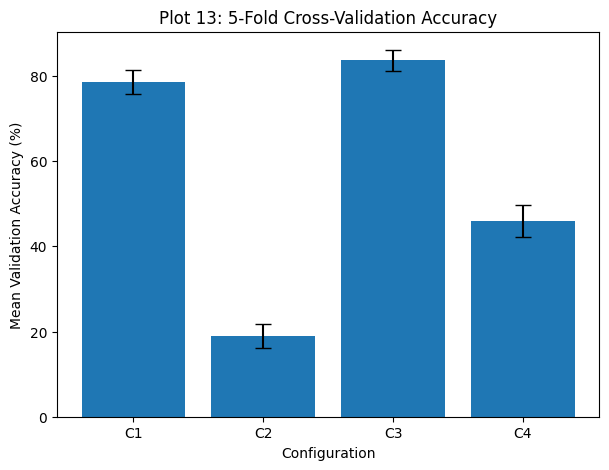

In [9]:
# Plot 13: 5-Fold CV Accuracy with error bars
plt.figure(figsize=(7,5))
plt.bar(cv_table.index, cv_table['Mean'], yerr=cv_table['SD'], capsize=6)
plt.xlabel('Configuration'); plt.ylabel('Mean Validation Accuracy (%)')
plt.title('Plot 13: 5-Fold Cross-Validation Accuracy')
plt.show()

In [12]:
best_config_name = cv_table['Mean'].idxmax()
best_config = configs[best_config_name]
print("Selected configuration:", best_config_name, best_config)

final_model, _ = build_model(init='he_normal', dropout_rate=best_config['dropout'], use_bn=True)
opt = (optimizers.Adam(learning_rate=best_config['lr']) if best_config['optimizer'] == 'adam'
       else optimizers.SGD(learning_rate=best_config['lr'], momentum=0.9))
final_model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start = time.time()
final_model.fit(X_cv, y_cv, batch_size=best_config['batch_size'], epochs=5, verbose=1)
train_time = time.time() - start

# Use the (shuffled) test set
random.shuffle(test_items)
ds_test = make_dataset(test_items)
X_test, y_test = dataset_to_numpy(ds_test, limit=CV_LIMIT)
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
y_pred = np.argmax(final_model.predict(X_test), axis=1)

precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall    = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1        = f1_score(y_test, y_pred, average='macro', zero_division=0)
num_params = final_model.count_params()

final_report = pd.DataFrame({
    'Metric': ['Mean CV Accuracy (%)', 'CV Standard Deviation', 'Test Accuracy (%)',
               'Precision', 'Recall', 'F1-score', 'Training Time (s)', 'Number of Parameters'],
    'Value': [cv_table.loc[best_config_name, 'Mean'], cv_table.loc[best_config_name, 'SD'],
              test_acc*100, precision, recall, f1, train_time, num_params]
})

final_report_display = final_report.copy()
final_report_display['Value'] = final_report_display['Value'].apply(lambda v: f"{v:.3f}")
final_report_display

Selected configuration: C3 {'lr': 0.001, 'batch_size': 16, 'dropout': 0.25, 'optimizer': 'adam'}
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.4263 - loss: 2.2445
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8675 - loss: 0.4630
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9350 - loss: 0.2013
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9575 - loss: 0.1480
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9800 - loss: 0.1098
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step


,Metric,Value
0,Mean CV Accuracy (%),83.625
1,CV Standard Deviation,2.437
2,Test Accuracy (%),88.000
3,Precision,0.881
4,Recall,0.877
5,F1-score,0.876
6,Training Time (s),19.121
7,Number of Parameters,2431845.000


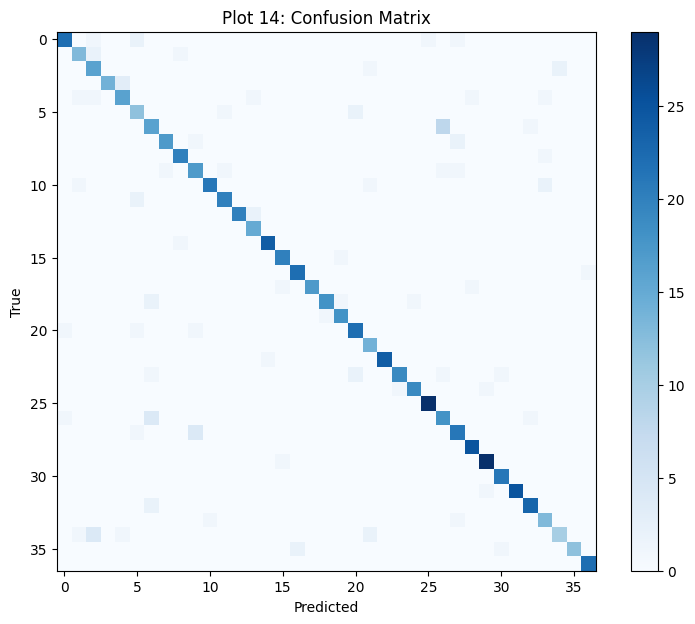

In [13]:
# Plot 14: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
plt.imshow(cm, cmap='Blues')
plt.title('Plot 14: Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.colorbar()
plt.show()

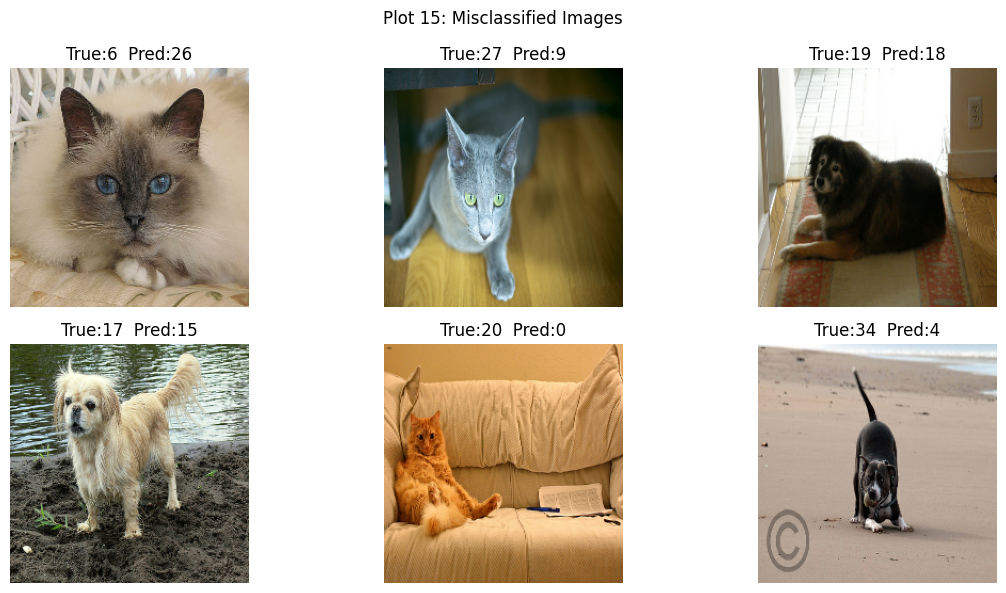

In [14]:
# Optional Plot 15: Misclassified Images
mis_idx = np.where(y_pred != y_test)[0][:6]
plt.figure(figsize=(12,6))
for i, idx in enumerate(mis_idx):
    plt.subplot(2, 3, i+1)
    img = (X_test[idx] + 1) / 2  # undo MobileNetV2 preprocessing, roughly, for display
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"True:{y_test[idx]}  Pred:{y_pred[idx]}")
    plt.axis('off')
plt.suptitle('Plot 15: Misclassified Images')
plt.tight_layout(); plt.show()

In [15]:
new_configs = {
    'New1': dict(lr=0.0001, batch_size=64, dropout=0.25, optimizer='adam'),
    'New2': dict(lr=0.001,  batch_size=16, dropout=0.5,  optimizer='sgd'),
}

new_cv_results = {}
for cname, cfg in new_configs.items():
    fold_accs = []
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_cv)):
        acc = build_and_train(X_cv[tr_idx], y_cv[tr_idx], X_cv[val_idx], y_cv[val_idx], cfg, epochs=15)
        fold_accs.append(acc * 100)
    new_cv_results[cname] = fold_accs

new_cv_table = pd.DataFrame(new_cv_results).T
new_cv_table.columns = [f'F{i+1}' for i in range(5)]
new_cv_table['Mean'] = new_cv_table[[f'F{i+1}' for i in range(5)]].mean(axis=1)
new_cv_table['SD']   = new_cv_table[[f'F{i+1}' for i in range(5)]].std(axis=1)

comparison_table = pd.concat([cv_table.loc[[best_config_name]], new_cv_table])
comparison_table

,F1,F2,F3,F4,F5,Mean,SD
C3,86.250001,82.499999,86.250001,81.250000,81.875002,83.625001,2.436699
New1,68.750000,64.999998,66.874999,64.999998,69.999999,67.124999,2.236069
New2,80.624998,85.000002,89.999998,83.125001,82.499999,84.250000,3.573994
